In [47]:
import os, pickle
from real_data import vendors, vendor_map, get_initial_states
from adoptionopinions_model import Simulation, Networks
from networks import complete
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
real_world_data = "vendor-ww-monthly-201407-202605.csv"
n = 1000
model_path = f"best_model_{n}.blk"
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
df = pd.read_csv(real_world_data)
df = df[vendors] / 100

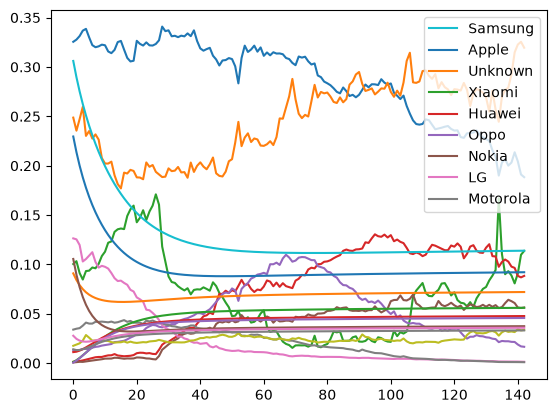

In [50]:
with open(model_path, "rb") as fd:
    SC, min_error = pickle.load(fd)

IS = get_initial_states(n=n, df=df, x0=SC.x0)
sim = Simulation(
           simulation_constants = SC,
           initial_states = IS,
           net = Networks(W=complete(n), V = complete(n)),
           window_size=len(df)
           )
for _ in range(len(df)):
    sim()
states = sim.get_adoption_states()
market_share_prediction = []
for vendor in vendors:
      index = vendor_map[vendor]
      market_share_prediction.append([state[index].mean(axis=0) for state in states])

o = len(df)
plt.plot(df[:o])
for i in range(len(market_share_prediction)):
    plt.plot(market_share_prediction[i][:o], label=vendors[i])
plt.legend()
plt.show()
